In [ ]:
%load_ext autoreload
%autoreload 2

import logging, sys
logger = logging.getLogger("molpot")
# logger.setLevel(logging.INFO)
# logger.addHandler(logging.StreamHandler(stream=sys.stdout))
import torch
import molpot as mpot
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of molpot.pipeline.dataset failed: Traceback (most recent call last):
  File "/opt/conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/opt/conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/opt/conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/opt/conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 335, in update_class
    if (old_obj == new_obj) is True:
        ^^^^^^^^^^^^^^^^^^
RuntimeError: Boolean value of Tensor with more than one value is ambiguous
]


In [24]:
qm9_ds = mpot.dataset.QM9("./data/qm9")
qm9_ds.prepare(total=None)

downloading...
downloading...
done
done


[autoreload of molpot.pipeline.dataset failed: Traceback (most recent call last):
  File "/opt/conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/opt/conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/opt/conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/opt/conda/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 335, in update_class
    if (old_obj == new_obj) is True:
        ^^^^^^^^^^^^^^^^^^
RuntimeError: Boolean value of Tensor with more than one value is ambiguous
]


end extract, cost 35.20s, average 0.00 s/file
end extract, cost 35.20s, average 0.00 s/file
parsing...
parsing...


100%|██████████| 133885/133885 [02:02<00:00, 1093.57it/s]

end parse, cost 178.68s
end parse, cost 178.68s


tensor(1809.2665)


[Frame(
     fields={
         atoms: Frame(
             fields={
                 R: Tensor(shape=torch.Size([16, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                 Z: Tensor(shape=torch.Size([16]), device=cpu, dtype=torch.int64, is_shared=False)},
             batch_size=torch.Size([]),
             device=None,
             is_shared=False),
         labels: Frame(
             fields={
                 Cv: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
                 G: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
                 H: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
                 U0: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
                 U: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
                 zpve: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.

In [ ]:
import bz2, tarfile, io

bz2_file = bz2.BZ2File("./qm9/qm9.tar.bz2")
bz2_bytes = bz2_file.read()

In [ ]:
tarfile.open(fileobj=io.BytesIO(bz2_bytes), mode='r')

In [ ]:
frames = qm9_ds._frames
key = ("labels", "U0")


Z = torch.cat([frame["atoms", "Z"] for frame in frames], dim=0)
elems = torch.unique(Z)

x = []
y = []
for frame in frames:
    count = torch.bincount(frame["atoms", "Z"]-1, minlength=max(elems))
    x.append(count.float())
    y.append(frame[key])

x = torch.stack(x)
y = torch.stack(y)
beta = torch.linalg.pinv(x.T @ x) @ x.T @ y
# Build a dictionary mapping each element to its fitted coefficient.
atomic_dress = {elem+1: e.item() for elem, e in enumerate(beta)}

# Compute the residual error (difference between the prediction and true values).
error = torch.matmul(x, beta) - y

# # substract the fitted energy from the true energy
# for frame in frames:
#     frame[key] -= torch.sum(beta[frame["atoms", "Z"]-1])
# print(torch.sqrt(torch.mean(error**2)))
# return frames


In [ ]:
atomic_dress

{1: -0.043857574462890625,
 2: -1.3951612309881511e-08,
 3: 1.947291572435006e-08,
 4: -1.7116263961725053e-08,
 5: -1.143562755601124e-08,
 6: 0.4027911424636841,
 7: 0.5869793891906738,
 8: 0.3779311180114746,
 9: 0.2052919566631317}

In [ ]:
for frame in frames:
    count = torch.bincount(frame["atoms", "Z"]-1, minlength=max(elems))
    break

count

tensor([10,  0,  0,  0,  0,  7,  1,  1,  0])

In [ ]:
e = []
for ee in qm9_ds:
    e.append(ee["labels", "U0"].items())

NameError: name 'qm9_ds' is not defined

In [ ]:
import tempfile
tempfile.gettempdir()

'/tmp'

In [ ]:
rmd17_ds = mpot.dataset.rMD17("aspirin", "./data")
rmd17_ds.prepare(total=1000, preprocess=[mpot.process.NeighborList(cutoff=5.0)])
train_ds, eval_ds = torch.utils.data.random_split(rmd17_ds, [0.95, 0.05])
train_dl = mpot.DataLoader(train_ds, batch_size=10)
eval_dl = mpot.DataLoader(eval_ds, batch_size=10)

tensor(6.0878)


In [ ]:
energy = []
for d in rmd17_ds:
    energy.append(d["labels", "energy"].item())

(array([ 1.,  0.,  1.,  0.,  0.,  1.,  1.,  3.,  0.,  1.,  0.,  0.,  1.,
         0.,  5.,  4.,  2.,  2.,  8.,  7., 10.,  6.,  8., 11.,  5.,  9.,
        14., 23., 15., 17., 20., 12., 22., 23., 21., 26., 21., 28., 21.,
        21., 18., 17., 25., 23., 30., 26., 29., 44., 25., 14., 24., 19.,
        19., 15., 28., 22., 21., 17., 17., 20., 14., 14., 10., 10., 15.,
         6.,  7., 12.,  5., 13., 10., 12.,  7.,  6.,  5.,  1.,  2.,  3.,
         3.,  3.,  1.,  2.,  1.,  0.,  2.,  0.,  2.,  0.,  2.,  2.,  0.,
         0.,  2.,  1.,  2.,  0.,  1.,  0.,  0.,  1.]),
 array([-17.9375  , -17.548125, -17.15875 , -16.769375, -16.38    ,
        -15.990625, -15.60125 , -15.211875, -14.8225  , -14.433125,
        -14.04375 , -13.654375, -13.265   , -12.875625, -12.48625 ,
        -12.096875, -11.7075  , -11.318125, -10.92875 , -10.539375,
        -10.15    ,  -9.760625,  -9.37125 ,  -8.981875,  -8.5925  ,
         -8.203125,  -7.81375 ,  -7.424375,  -7.035   ,  -6.645625,
         -6.25625 ,  -5.86

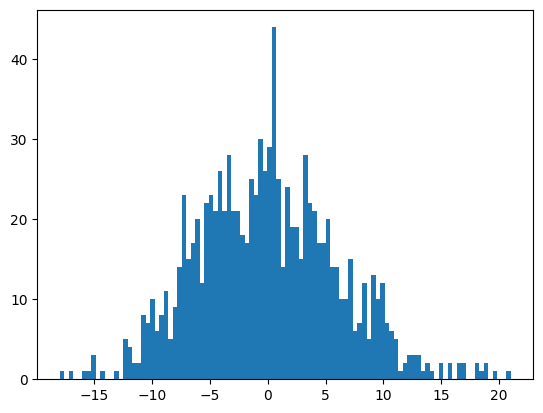

In [ ]:
plt.hist(energy, bins=100)

In [ ]:
rmd17_dl = mpot.DataLoader(
    rmd17_ds,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=False,
    drop_last=False,
)

In [ ]:
for batch in rmd17_dl:
    print(batch)
    break

TensorDict(
    fields={
        atoms: TensorDict(
            fields={
                R: Tensor(shape=torch.Size([2, 21, 3]), device=cpu, dtype=torch.float32, is_shared=True),
                Z: Tensor(shape=torch.Size([2, 21]), device=cpu, dtype=torch.int32, is_shared=True)},
            batch_size=torch.Size([2]),
            device=None,
            is_shared=False),
        cell: NonTensorData(data=None, batch_size=torch.Size([2]), device=None),
        labels: TensorDict(
            fields={
                energy: Tensor(shape=torch.Size([2, 1]), device=cpu, dtype=torch.float32, is_shared=True),
                forces: Tensor(shape=torch.Size([2, 21, 3]), device=cpu, dtype=torch.float32, is_shared=True)},
            batch_size=torch.Size([2]),
            device=None,
            is_shared=False),
        pairs: TensorDict(
            fields={
                diff: NestedTensor(shape=torch.Size([2, j27, 3]), device=cpu, dtype=torch.float32, is_shared=False),
               